# GLF

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import math
import torch
from torch import nn
import torch.nn.functional as F

In [2]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [3]:
class GLF(nn.Module):
    def __init__(self):
        super().__init__()
        self.A = nn.Parameter(torch.rand(1))
        self.B = nn.Parameter(torch.rand(1))
        self.C = nn.Parameter(torch.rand(1))
        self.K = nn.Parameter(torch.rand(1))
        self.Q = nn.Parameter(torch.rand(1))
        self.V = nn.Parameter(torch.rand(1))
    
    def forward(self, x):
        term1 = self.A
        nominator_term2 = self.K - self.A
        denominator_term2 = (self.C + self.Q*(torch.exp(-1*self.B*x))) ** (1/self.V)
        return term1 + (nominator_term2/denominator_term2)
        
    def set_coef(self,
        A=-1, B=1, C=1, K=1, Q=1, V=1):
        one=torch.tensor([1.])
        sd={
            'A': one*A,
            'B': one*B,
            'C': one*C,
            'K': one*K,
            'Q': one*Q,
            'V': one*V,
        }
        self.load_state_dict(sd)

In [4]:
model = GLF()

In [5]:
model.state_dict()

OrderedDict([('A', tensor([0.3341])),
             ('B', tensor([0.4733])),
             ('C', tensor([0.9775])),
             ('K', tensor([0.8948])),
             ('Q', tensor([0.3114])),
             ('V', tensor([0.7103]))])

In [6]:
model.set_coef()

In [7]:
model.state_dict()

OrderedDict([('A', tensor([-1.])),
             ('B', tensor([1.])),
             ('C', tensor([1.])),
             ('K', tensor([1.])),
             ('Q', tensor([1.])),
             ('V', tensor([1.]))])

In [8]:
x = torch.linspace(-8, 8, 2000)

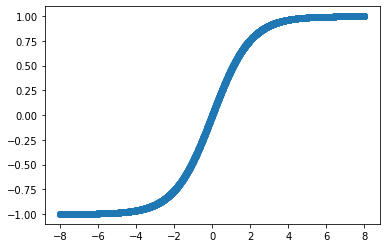

In [9]:
with torch.no_grad():
    plt.scatter(x, model(x))

In [ ]:
GLF_unitC: -12.161 |A,   1.000 |B,  12.161 |K,   1.000 |Q,   1.000 |V


OrderedDict([('A', tensor([-12.1610])), ('B', tensor([-0.2000])), ('C', tensor([1.])), ('K', tensor([12.1610])), ('Q', tensor([1.])), ('V', tensor([1.]))])


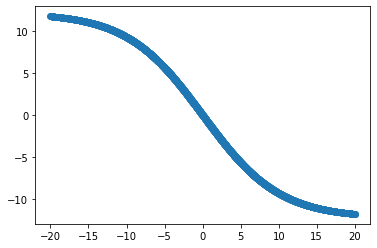

In [72]:
model.set_coef(A=-12.161, K=12.161, B=-0.2, Q=1, V=1, C=1)
print(model.state_dict())
with torch.no_grad():
    y=model(x)
    plt.scatter(x, y)

OrderedDict([('A', tensor([-12.1610])), ('B', tensor([1.])), ('C', tensor([1.])), ('K', tensor([12.1610])), ('Q', tensor([1.])), ('V', tensor([1.]))])


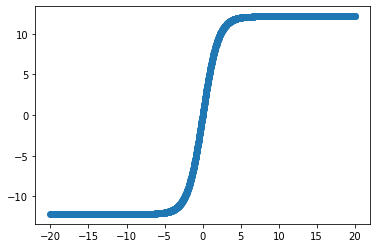

In [63]:
model.set_coef(A=-12.161, K=12.161, B=1, Q=1, V=1, C=1)
print(model.state_dict())
with torch.no_grad():
    y=model(x)
    plt.scatter(x, y)

OrderedDict([('A', tensor([-11.8510])), ('B', tensor([0.2300])), ('C', tensor([1.])), ('K', tensor([11.2290])), ('Q', tensor([4.2700])), ('V', tensor([2.4860]))])


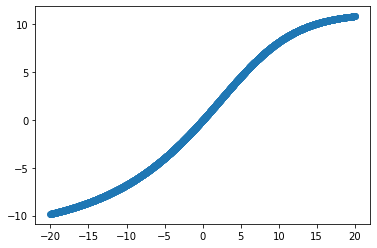

In [61]:
model.set_coef(A=-11.851, K=11.229, B=0.230, Q=4.270, V=2.486, C=1)
print(model.state_dict())
with torch.no_grad():
    y=model(x)
    plt.scatter(x, y)

In [62]:
y

tensor([-9.8297, -9.8260, -9.8222,  ..., 10.8386, 10.8404, 10.8421])

OrderedDict([('A', tensor([0.])), ('B', tensor([1.])), ('C', tensor([1.])), ('K', tensor([1.])), ('Q', tensor([10.])), ('V', tensor([1.]))])


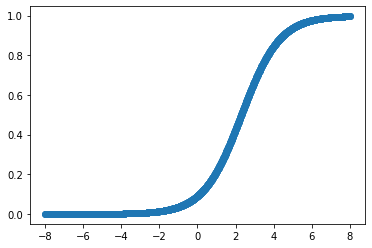

In [18]:
model.set_coef(A=0, K=1, B=1, Q=10, V=1, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([0.])), ('B', tensor([1.])), ('C', tensor([1.])), ('K', tensor([1.])), ('Q', tensor([1.])), ('V', tensor([2.]))])


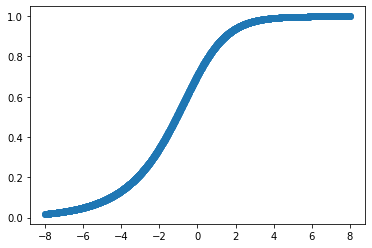

In [21]:
model.set_coef(A=0, K=1, B=1, Q=1, V=2, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([0.])), ('B', tensor([1.])), ('C', tensor([1.])), ('K', tensor([1.])), ('Q', tensor([2.])), ('V', tensor([2.]))])


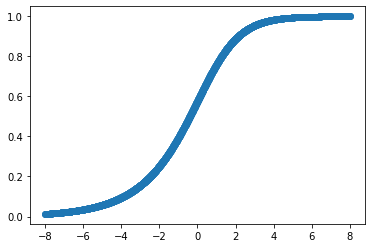

In [22]:
model.set_coef(A=0, K=1, B=1, Q=2, V=2, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([0.])), ('B', tensor([1.])), ('C', tensor([1.])), ('K', tensor([1.])), ('Q', tensor([1.])), ('V', tensor([1.]))])


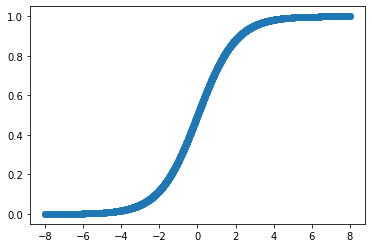

In [24]:
model.set_coef(A=0, K=1, B=1, Q=1, V=1, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([0.])), ('B', tensor([10.])), ('C', tensor([1.])), ('K', tensor([1.])), ('Q', tensor([1.])), ('V', tensor([1.]))])


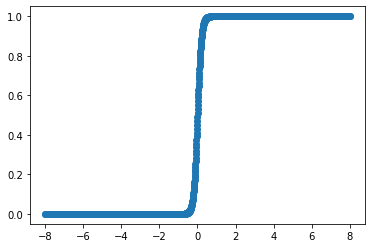

In [26]:
model.set_coef(A=0, K=1, B=10, Q=1, V=1, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([0.])), ('B', tensor([10.])), ('C', tensor([1.])), ('K', tensor([1.])), ('Q', tensor([1.])), ('V', tensor([1.]))])


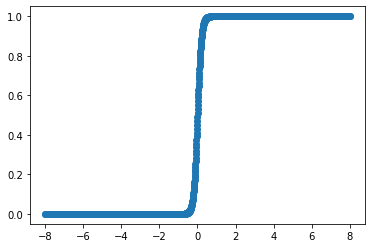

In [33]:
model.set_coef(A=0, K=1, B=10, Q=1, V=1, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([1.7130])), ('B', tensor([1.2860])), ('C', tensor([1.])), ('K', tensor([0.7780])), ('Q', tensor([1.4200])), ('V', tensor([-1.6590]))])


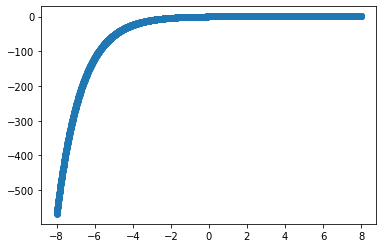

In [55]:
# 1.713 |A,   1.286 |B,   0.778 |K,   1.420 |Q,  -1.659 |V

model.set_coef(A=1.713, K=0.778, B=1.286, Q=1.420, V=-1.659, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([1.7130])), ('B', tensor([1.2860])), ('C', tensor([1.])), ('K', tensor([0.7780])), ('Q', tensor([1.4200])), ('V', tensor([-1.6590]))])


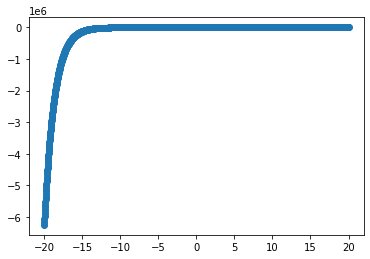

In [59]:
model.set_coef(A=1.713, K=0.778, B=1.286, Q=1.420, V=-1.659, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

OrderedDict([('A', tensor([1.7130])), ('B', tensor([1.2860])), ('C', tensor([1.])), ('K', tensor([0.7780])), ('Q', tensor([1.4200])), ('V', tensor([-1.6590]))])


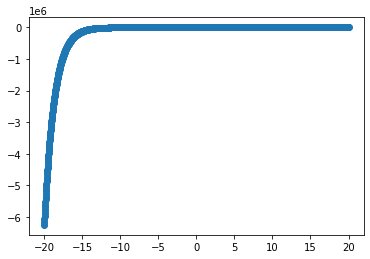

In [58]:
x = torch.linspace(-20, 20, 2000)
model.set_coef(A=1.713, K=0.778, B=1.286, Q=1.420, V=-1.659, C=1)
print(model.state_dict())
with torch.no_grad():
    plt.scatter(x, model(x))

In [57]:
x

tensor([-8.0000, -7.9920, -7.9840,  ...,  7.9840,  7.9920,  8.0000])

In [73]:
# synthetic dataset that behaves like a ReLu

In [56]:
model(x)

tensor([-568.2081, -564.6831, -561.1799,  ...,    0.7780,    0.7780,
           0.7780], grad_fn=<AddBackward0>)

In [80]:
y = 0.5*x + 5
y = torch.clamp(y, min=2,max=7)

In [49]:
z = torch.zeros((1))
y = torch.nn.functional.relu(x)
# y = torch.clamp(y, min=2,max=7)

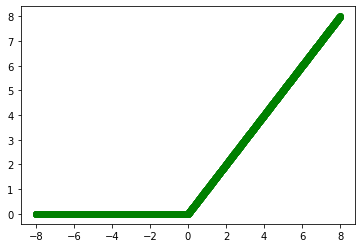

In [50]:
plt.scatter(x, y, c='g')

In [51]:
model = GLF()
loss_fn = nn.MSELoss()
learning_rate = 1e-4
epoch = 10000
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [52]:
for e in range(epoch):
    yhat = model(x)
    loss = loss_fn(yhat, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if e % 200 == 199:
        print(e, loss.item())

199 0.5458385348320007
399 0.23094412684440613
599 0.12367589771747589
799 0.07955160737037659
999 0.05922175198793411
1199 0.04911777377128601
1399 0.043808236718177795
1599 0.04088649898767471
1799 0.039205994457006454
1999 0.03819170221686363
2199 0.03754391893744469
2399 0.03710203617811203
2599 0.036778002977371216
2799 0.03652295097708702
2999 0.036309223622083664
3199 0.03612111508846283
3399 0.03594963625073433
3599 0.03578951954841614
3799 0.03563768044114113
3999 0.03549235686659813
4199 0.035352446138858795
4399 0.03521721065044403
4599 0.035086240619421005
4799 0.03495919704437256
4999 0.0348360650241375
5199 0.03471656143665314
5399 0.03460054099559784
5599 0.034487783908843994
5799 0.03437821939587593
5999 0.03427189588546753
6199 0.034168556332588196
6399 0.03406820073723793
6599 0.033970825374126434
6799 0.03387613222002983
6999 0.03378422185778618
7199 0.03369499742984772
7399 0.033608295023441315
7599 0.0335240513086319
7799 0.03344229608774185
7999 0.0333628803491592

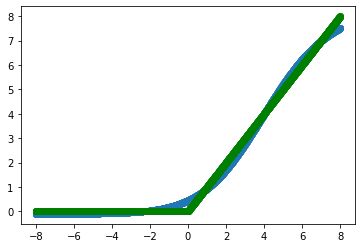

In [53]:
with torch.no_grad():
    plt.scatter(x, model(x))
    plt.scatter(x,y,color='g')
    plt.show()

In [100]:
# what if a relu function
y = F.relu(x)

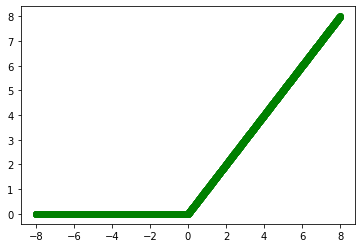

In [104]:
plt.scatter(x, y, c='g')

In [105]:
model = GLF()
loss_fn = nn.MSELoss()
learning_rate = 1e-4
epoch = 10000
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [106]:
for e in range(epoch):
    yhat = model(x)
    loss = loss_fn(yhat, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if e % 200 == 199:
        print(e, loss.item())

199 7.229012966156006
399 6.29796028137207
599 3.6942853927612305
799 0.6063862442970276
999 0.4840438961982727
1199 0.39847108721733093
1399 0.3362070620059967
1599 0.28958362340927124
1799 0.2538352608680725
1999 0.22584035992622375
2199 0.20348086953163147
2399 0.18528728187084198
2599 0.17022071778774261
2799 0.15753689408302307
2999 0.1466953307390213
3199 0.13729993999004364
3399 0.12905700504779816
3599 0.12174639850854874
3799 0.11520170420408249
3999 0.10929518193006516
4199 0.10392805188894272
4399 0.09902272373437881
4599 0.09451781958341599
4799 0.09036359190940857
4999 0.08651978522539139
5199 0.08295268565416336
5399 0.07963433116674423
5599 0.07654077559709549
5799 0.07365158945322037
5999 0.07094904780387878
6199 0.06841767579317093
6399 0.06604370474815369
6599 0.0638149306178093
6799 0.061720557510852814
6999 0.05975073203444481
7199 0.05789656564593315
7399 0.05615014582872391
7599 0.054503992199897766
7799 0.05295150727033615
7999 0.0514865517616272
8199 0.050103392

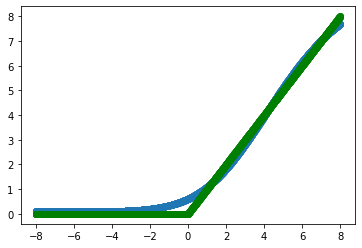

In [107]:
with torch.no_grad():
    plt.scatter(x, model(x))
    plt.scatter(x,y,color='g')
    plt.show()

In [108]:
model.state_dict()

OrderedDict([('A', tensor([0.1030])),
             ('B', tensor([0.4160])),
             ('C', tensor([0.3856])),
             ('K', tensor([0.9770])),
             ('Q', tensor([0.8590])),
             ('V', tensor([0.4053]))])

In [110]:
# K value is not usable because it doesnt close to upper asymtote

In [111]:
class GLF_unitC(nn.Module):
    def __init__(self):
        super().__init__()
        self.A = nn.Parameter(torch.rand(1))
        self.B = nn.Parameter(torch.rand(1))
        self.K = nn.Parameter(torch.rand(1))
        self.Q = nn.Parameter(torch.rand(1))
        self.V = nn.Parameter(torch.rand(1))
    
    def forward(self, x):
        term1 = self.A
        nominator_term2 = self.K - self.A
        denominator_term2 = (1 + self.Q*(torch.exp(-1*self.B*x))) ** (1/self.V)
        return term1 + (nominator_term2/denominator_term2)
        
    def set_coef(self,
        A=-1, B=1, K=1, Q=1, V=1):
        one=torch.tensor([1.])
        sd={
            'A': one*A,
            'B': one*B,
            'K': one*K,
            'Q': one*Q,
            'V': one*V,
        }
        self.load_state_dict(sd)

In [113]:
model = GLF_unitC()
loss_fn = nn.MSELoss()
learning_rate = 1e-4
epoch = 10000
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [114]:
for e in range(epoch):
    yhat = model(x)
    loss = loss_fn(yhat, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if e % 200 == 199:
        print(e, loss.item())

199 8.274608612060547
399 8.089818954467773
599 7.9076714515686035
799 7.726500511169434
999 7.54619836807251
1199 7.367453098297119
1399 7.191099166870117
1599 7.017843723297119
1799 6.848203182220459
1999 6.682531356811523
2199 6.521050930023193
2399 6.363886833190918
2599 6.211089611053467
2799 6.062656879425049
2999 5.918542385101318
3199 5.778670787811279
3399 5.642949104309082
3599 5.511263370513916
3799 5.38348913192749
3999 5.259500026702881
4199 5.139160633087158
4399 5.022335529327393
4599 4.9088921546936035
4799 4.798699378967285
4999 4.691629886627197
5199 4.587562561035156
5399 4.486381530761719
5599 4.387975215911865
5799 4.292242050170898
5999 4.1990885734558105
6199 4.10842227935791
6399 4.020164489746094
6599 3.9342334270477295
6799 3.8505587577819824
6999 3.769076347351074
7199 3.689723253250122
7399 3.6124391555786133
7599 3.5371689796447754
7799 3.463857889175415
7999 3.3924543857574463
8199 3.3229072093963623
8399 3.2551684379577637
8599 3.18918776512146
8799 3.124

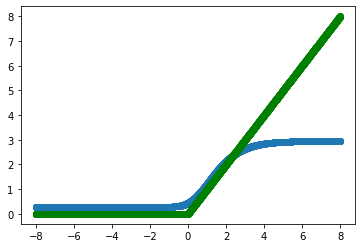

In [115]:
with torch.no_grad():
    plt.scatter(x, model(x))
    plt.scatter(x,y,color='g')
    plt.show()

In [116]:
model.state_dict()

OrderedDict([('A', tensor([0.2901])),
             ('B', tensor([1.0856])),
             ('K', tensor([2.9552])),
             ('Q', tensor([0.3578])),
             ('V', tensor([0.1080]))])

In [ ]:
# Now K is the asymtotic value

In [117]:
with torch.no_grad():
    zeropoint = model(torch.tensor([0.0]))

In [118]:
zeropoint

tensor([0.4470])